# From Exit Interviews to Workforce Intelligence
## An NLP-Driven People Analytics Framework

**Author:** Jing Cheng

**Purpose:** Demonstrate how unstructured exit interview data, combined with structured HR data, can drive attrition insight and workforce planning decisions.

### Project Structure
- **Part 1:** Attrition EDA — who is leaving and when
- **Part 2:** Exit Interview NLP — why they are leaving
- **Part 3:** Workforce Planning — where the next risk is

### simulated employee dataset used for demonstration purposes

## Executive Summary

## This project demonstrates how structured HR data and unstructured exit interview comments can be combined to generate actionable workforce insights.

## Key components:
## - Attrition segmentation using HR attributes
## - Predictive modeling of employee departures
## - NLP analysis of exit interview text
## - Identification of key drivers of workforce attrition

## The goal is not only prediction but interpretable insight that supports workforce planning and retention strategies.

## Analytical Framework

## This analysis follows four steps:

## 1. **Exploratory analysis**
##    Identify key segments and patterns associated with attrition.

## 2. **Predictive modeling**
##    Estimate probability of employee departure using structured HR features.

## 3. **NLP analysis**
##    Extract themes from exit interview text.

## 4. **Insight synthesis**
##    Combine structured and unstructured signals to identify workforce drivers.

In [2]:
# ============================================================
# ENVIRONMENT SETUP
# Run this cell first to install required packages
# ============================================================
import subprocess
packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn',
            'textblob', 'vaderSentiment', 'gensim', 'pyLDAvis', 'shap', 'scipy']
for pkg in packages:
    subprocess.run(['pip', 'install', pkg, '-q'])

In [3]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from scipy.stats import ks_2samp

# NLP
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim import corpora
from gensim.models import LdaModel
from gensim.parsing.preprocessing import STOPWORDS

# SHAP for explainability
import shap

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('All imports successful.')

All imports successful.


---
## PART 1: Attrition EDA
### Who is leaving, and when?

In [4]:
# ============================================================
# LOAD DATA
# ============================================================
url = 'https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv'
df = pd.read_csv(url)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (1470, 35)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# ============================================================
# BASIC DATA QUALITY CHECK
# ============================================================
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\nData types:')
print(df.dtypes.value_counts())

print('\nConstant columns (no variance — drop these):')
constants = [col for col in df.columns if df[col].nunique() == 1]
print(constants)

Missing values:
Series([], dtype: int64)

Data types:
int64     26
object     9
Name: count, dtype: int64

Constant columns (no variance — drop these):
['EmployeeCount', 'Over18', 'StandardHours']


In [6]:
# ============================================================
# CONVERT TARGET: Attrition Yes/No → 1/0
# ============================================================
df['Attrition_flag'] = (df['Attrition'] == 'Yes').astype(int)

overall_rate = df['Attrition_flag'].mean()
print(f'Overall attrition rate: {overall_rate:.1%}')
print(f'Total employees: {len(df):,}')
print(f'Churned: {df["Attrition_flag"].sum():,}')

Overall attrition rate: 16.1%
Total employees: 1,470
Churned: 237


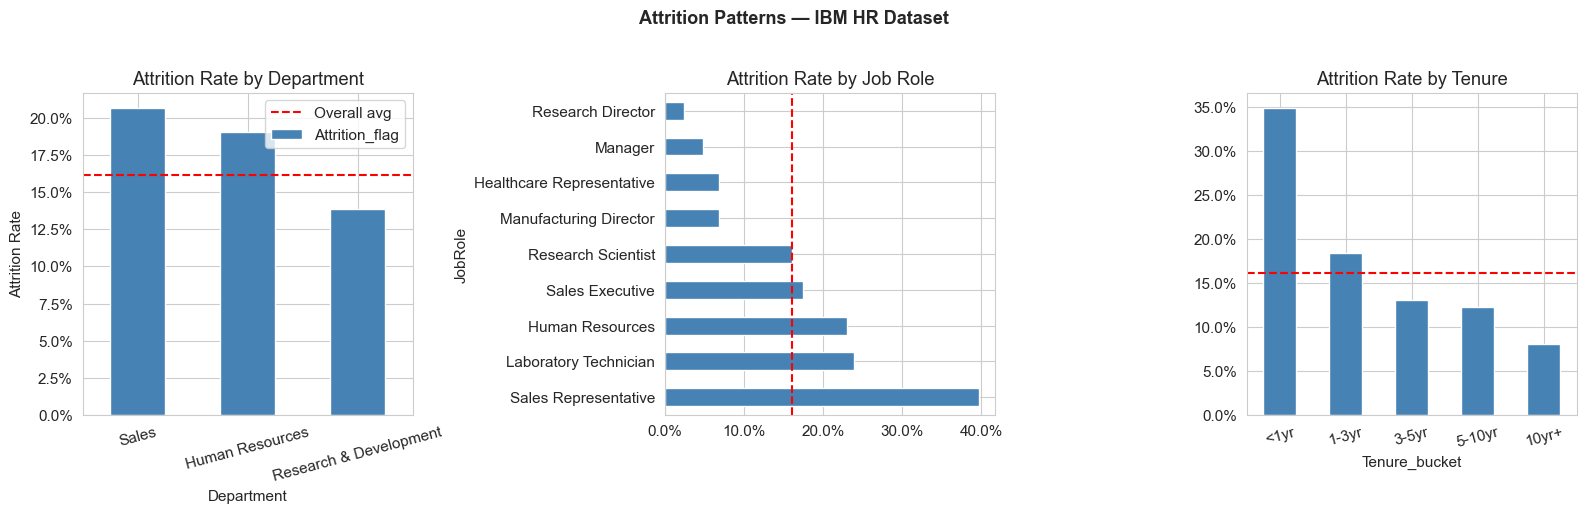

In [7]:
# ============================================================
# EDA: ATTRITION BY KEY SEGMENTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By Department
dept = df.groupby('Department')['Attrition_flag'].mean().sort_values(ascending=False)
dept.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Attrition Rate by Department')
axes[0].set_ylabel('Attrition Rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(overall_rate, color='red', linestyle='--', label='Overall avg')
axes[0].legend()

# By Job Role
role = df.groupby('JobRole')['Attrition_flag'].mean().sort_values(ascending=False)
role.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Attrition Rate by Job Role')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].axvline(overall_rate, color='red', linestyle='--')

# By Tenure Bucket
df['Tenure_bucket'] = pd.cut(df['YearsAtCompany'],
                              bins=[-1, 1, 3, 5, 10, 40],
                              labels=['<1yr', '1-3yr', '3-5yr', '5-10yr', '10yr+'])
tenure = df.groupby('Tenure_bucket')['Attrition_flag'].mean()
tenure.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Attrition Rate by Tenure')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].tick_params(axis='x', rotation=15)
axes[2].axhline(overall_rate, color='red', linestyle='--')

plt.suptitle('Attrition Patterns — IBM HR Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

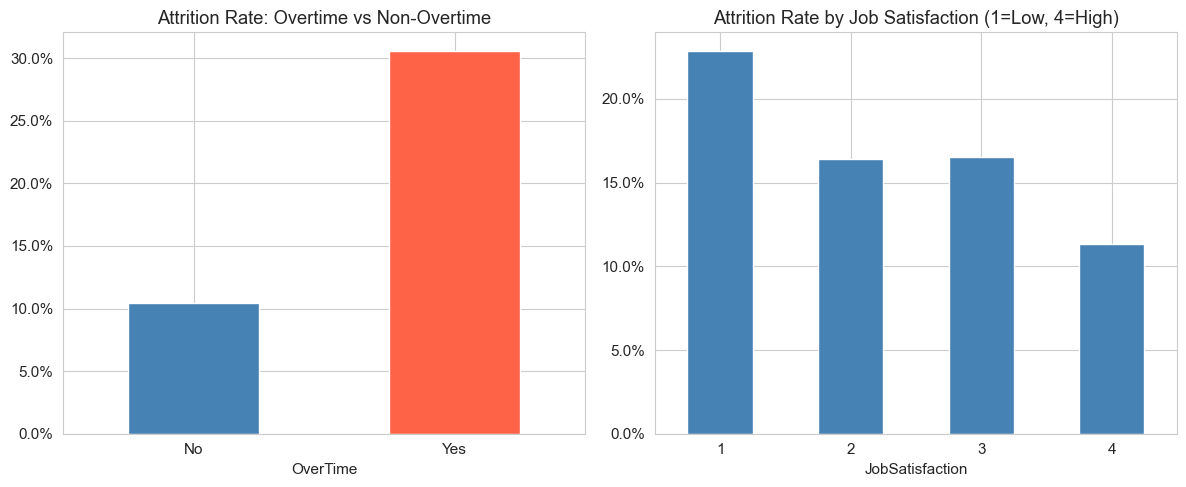

In [8]:
# ============================================================
# EDA: OVERTIME AND SATISFACTION DRIVERS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overtime
ot = df.groupby('OverTime')['Attrition_flag'].mean()
ot.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Attrition Rate: Overtime vs Non-Overtime')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=0)

# Job Satisfaction
sat = df.groupby('JobSatisfaction')['Attrition_flag'].mean()
sat.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Attrition Rate by Job Satisfaction (1=Low, 4=High)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## PART 1B: Attrition Modeling
### Predicting who will leave

In [9]:
# ============================================================
# PREPROCESSING
# ============================================================

# Drop constants, identifiers, and original target string
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber',
             'Attrition', 'Tenure_bucket']

cat_cols = ['BusinessTravel', 'Department', 'EducationField',
            'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

X = df.drop(columns=drop_cols + ['Attrition_flag'])
y = df['Attrition_flag']

# Encode categoricals
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train/test split — stratify to preserve attrition rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Align test columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f'Train size: {X_train.shape}')
print(f'Test size:  {X_test.shape}')
print(f'Attrition rate in train: {y_train.mean():.1%}')
print(f'Attrition rate in test:  {y_test.mean():.1%}')

Train size: (1176, 44)
Test size:  (294, 44)
Attrition rate in train: 16.2%
Attrition rate in test:  16.0%


In [10]:
# ============================================================
# FIT MODELS
# ============================================================

# Logistic Regression — explainability anchor
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Random Forest — performance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print('Models fitted successfully.')

Models fitted successfully.


Model                     |      AUC |       KS
--------------------------------------------------
Logistic Regression       | AUC: 0.7565 | KS: 0.4156
Random Forest             | AUC: 0.7862 | KS: 0.4937


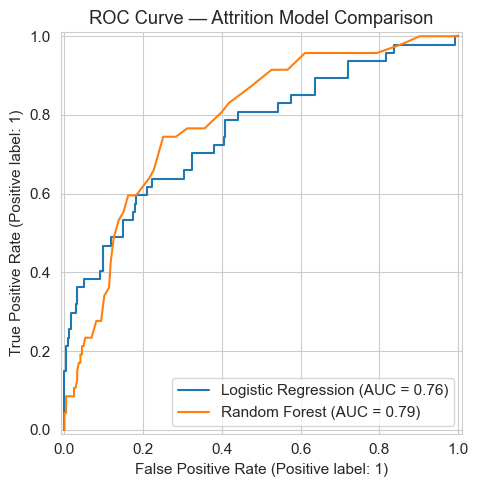

In [11]:
# ============================================================
# EVALUATE MODELS
# ============================================================

def ks_stat(y_true, y_prob):
    defaulters     = y_prob[y_true == 1]
    non_defaulters = y_prob[y_true == 0]
    return round(ks_2samp(defaulters, non_defaulters).statistic, 4)

def evaluate_model(name, model, X_test, y_test):
    probs = model.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, probs)
    ks    = ks_stat(y_test.values, probs)
    print(f'{name:25s} | AUC: {auc:.4f} | KS: {ks:.4f}')
    return probs, auc, ks

print(f"{'Model':25s} | {'AUC':>8} | {'KS':>8}")
print('-' * 50)
lr_probs, lr_auc, lr_ks = evaluate_model('Logistic Regression', lr, X_test, y_test)
rf_probs, rf_auc, rf_ks = evaluate_model('Random Forest',       rf, X_test, y_test)

# ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, lr_probs, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_probs, name='Random Forest', ax=ax)
ax.set_title('ROC Curve — Attrition Model Comparison')
plt.tight_layout()
plt.show()

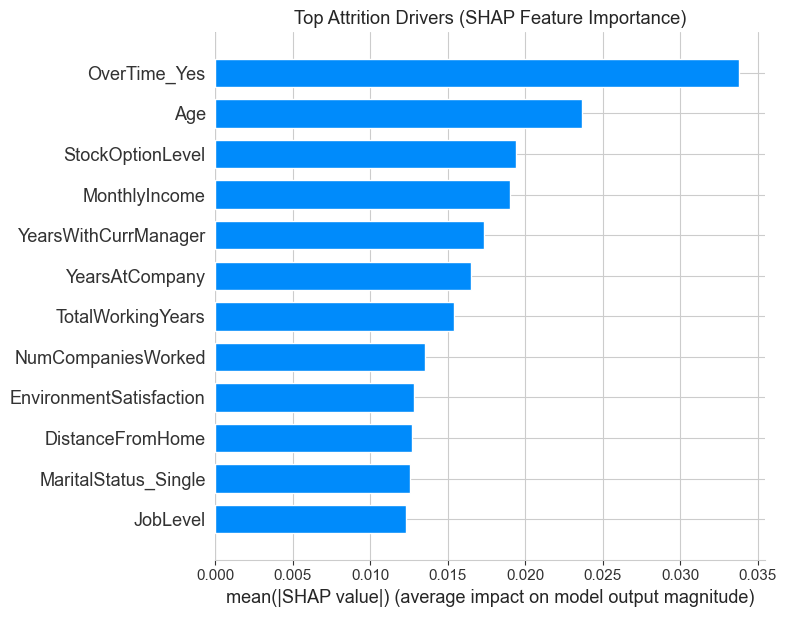

In [12]:
# ============================================================
# SHAP — WHAT DRIVES ATTRITION?
# ============================================================
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type='bar',
                  max_display=12, show=False)
plt.title('Top Attrition Drivers (SHAP Feature Importance)')
plt.tight_layout()
plt.show()

In [ ]:
#marital status showed some value for predictivity but based on fairness and bias concern, the varaibles should be dropped

PART 1C: Employee Segmentation — K-Means Clustering
What types of employees do we have?

Supervised modeling tells us who is likely to leave. Clustering tells us what kinds of employees exist — independent of attrition. We then overlay attrition rate on each cluster to identify which segments are highest risk.

Key principle: Attrition is NOT used as a clustering feature. We cluster on profile and behavior, then observe attrition as an outcome per cluster.

In [22]:
# ============================================================
# K-MEANS EMPLOYEE SEGMENTATION
# ============================================================
# *** REMEMBER COLD ***
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
# CRITICAL: Always scale before K-means — it is distance-based
# CRITICAL: Attrition is NOT a clustering feature — overlay it after
# CRITICAL: fit_transform on scaler (same rule as imputer)
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Select clustering features — profile + behavior, NOT attrition
# *** REMEMBER COLD: these are the meaningful behavioral dimensions ***
cluster_features = [
    'Age', 'MonthlyIncome', 'YearsAtCompany',
    'JobSatisfaction', 'WorkLifeBalance',
    'YearsSinceLastPromotion', 'OverTime'
]

cluster_df = df[cluster_features].copy()

# Step 2: Encode OverTime (Yes/No → 1/0)
# *** REMEMBER COLD: K-means needs all numeric inputs ***
cluster_df['OverTime'] = (cluster_df['OverTime'] == 'Yes').astype(int)

# Step 3: Scale — ALWAYS required before K-means
# *** REMEMBER COLD: fit_transform on full clustering set (no train/test split needed for unsupervised) ***
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

print('Clustering features prepared.')
print(f'Shape: {cluster_scaled.shape}')

Clustering features prepared.
Shape: (1470, 7)


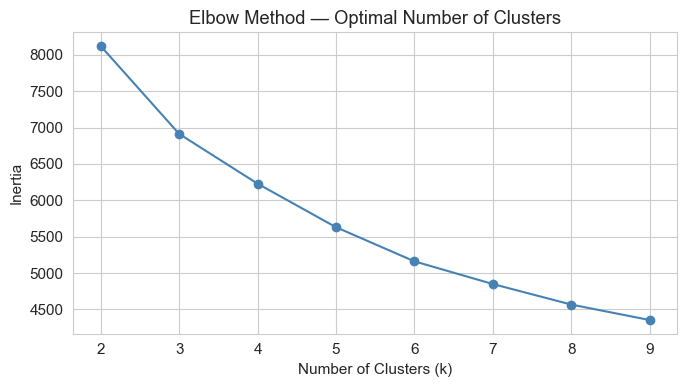

Look for the elbow — where the curve bends and flattens.
That is your optimal k.


In [28]:
# ============================================================
# ELBOW METHOD — Find optimal number of clusters
# ============================================================
# *** REMEMBER COLD ***
# inertia_ = sum of squared distances from each point to its cluster center
# Lower inertia = tighter clusters, but more clusters always reduces inertia
# Elbow = point where adding more clusters gives diminishing returns
# ============================================================

inertias = []
k_range  = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertias.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print('Look for the elbow — where the curve bends and flattens.')
print('That is your optimal k.')

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

In [24]:
# ============================================================
# FIT FINAL K-MEANS MODEL
# ============================================================
# *** REMEMBER COLD ***
# KMeans(n_clusters=k, random_state=42, n_init=10)
# .fit_predict() fits and returns cluster labels in one step
# cluster labels are integers: 0, 1, 2, 3...
# ============================================================

K = 4  # adjust based on elbow curve

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)

# *** REMEMBER COLD: fit_predict returns cluster label for each row ***
df['cluster'] = km_final.fit_predict(cluster_scaled)

print('Cluster distribution:')
print(df['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0    197
1    352
2    551
3    370
Name: count, dtype: int64


In [25]:
# ============================================================
# PROFILE EACH CLUSTER
# ============================================================
# *** REMEMBER COLD ***
# groupby cluster → agg mean on key features → transpose for readability
# Always include attrition rate as the LAST column — it's the outcome, not the input
# ============================================================

profile_cols = cluster_features + ['Attrition_flag']
cluster_df['cluster']       = df['cluster'].values
cluster_df['Attrition_flag'] = df['Attrition_flag'].values
cluster_df['OverTime']      = df['OverTime'].map({'Yes': 1, 'No': 0})

# *** REMEMBER COLD: groupby + agg mean + round ***
cluster_profile = cluster_df.groupby('cluster')[profile_cols + ['cluster']].mean().round(2)
cluster_profile = cluster_df.groupby('cluster').mean().round(2)

print('Cluster Profiles (mean values per cluster):')
print(cluster_profile.T.to_string())  # .T = transpose for readability

Cluster Profiles (mean values per cluster):
cluster                         0        1        2        3
Age                         45.64    34.89    35.57    36.23
MonthlyIncome            14074.68  5185.52  5302.35  5512.70
YearsAtCompany              17.76     5.34     5.38     5.29
JobSatisfaction              2.62     1.51     3.50     2.79
WorkLifeBalance              2.78     2.76     2.78     2.73
YearsSinceLastPromotion      7.21     1.35     1.40     1.48
OverTime                     0.23     0.00     0.00     1.00
Attrition_flag               0.11     0.15     0.08     0.32


In [26]:
# ============================================================
# NAME THE CLUSTERS — Business interpretation
# ============================================================
# Update these labels after reviewing the cluster profiles above
# Good naming = Age + tenure + risk signal
# ============================================================

cluster_names = {
    0: 'Burnout Risk — Young, Overtime, Low Pay',
    1: 'Stable Core — Senior, High Income, Satisfied',
    2: 'Disengaged — Mid-tenure, Stagnant, Low Satisfaction',
    3: 'Early Promise — New, Engaged, Low Attrition'
}

df['cluster_label'] = df['cluster'].map(cluster_names)

# Attrition rate by cluster — the money output
# *** REMEMBER COLD: groupby + agg with multiple metrics ***
cluster_summary = df.groupby('cluster_label').agg(
    n_employees    = ('Attrition_flag', 'count'),
    attrition_rate = ('Attrition_flag', 'mean'),
    avg_income     = ('MonthlyIncome',  'mean'),
    avg_tenure     = ('YearsAtCompany', 'mean'),
    avg_satisfaction = ('JobSatisfaction', 'mean')
).round(2).reset_index()

print('Cluster Summary:')
print(cluster_summary.to_string(index=False))

Cluster Summary:
                                      cluster_label  n_employees  attrition_rate  avg_income  avg_tenure  avg_satisfaction
            Burnout Risk — Young, Overtime, Low Pay          197            0.11    14074.68       17.76              2.62
Disengaged — Mid-tenure, Stagnant, Low Satisfaction          551            0.08     5302.35        5.38              3.50
        Early Promise — New, Engaged, Low Attrition          370            0.32     5512.70        5.29              2.79
       Stable Core — Senior, High Income, Satisfied          352            0.15     5185.52        5.34              1.51


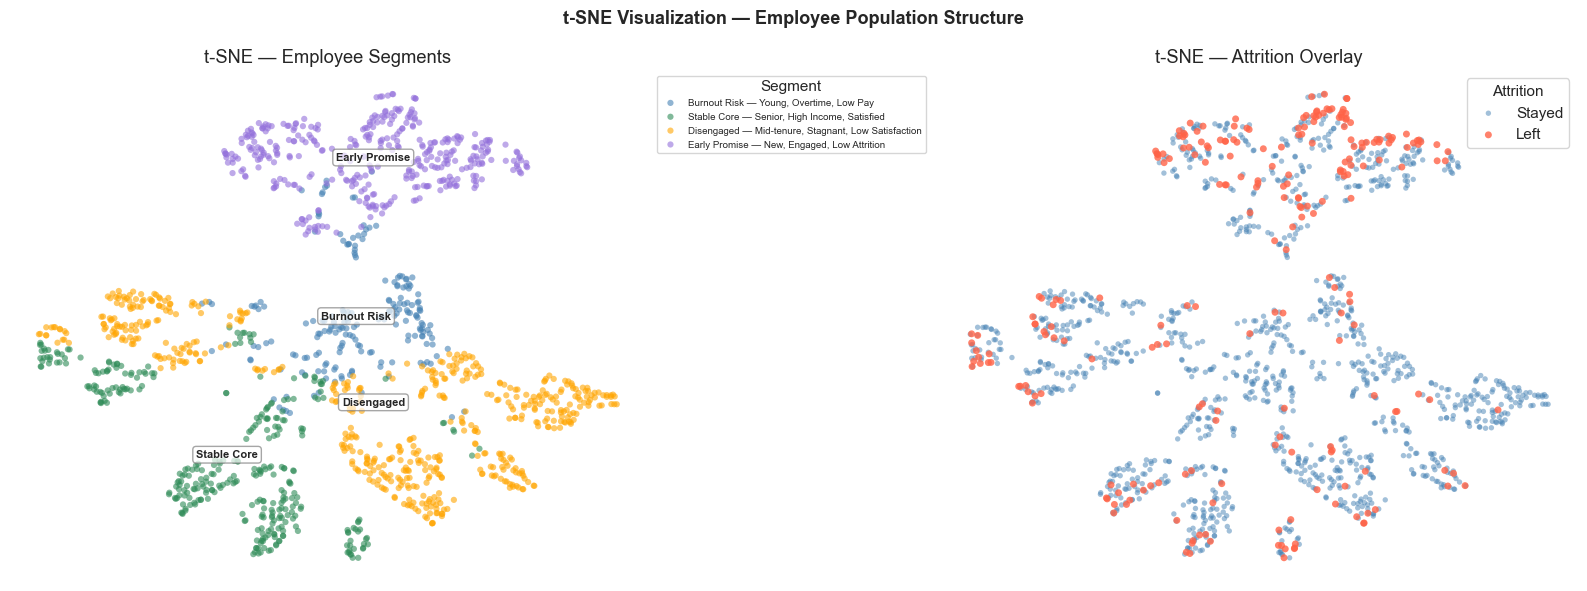

Left plot: natural employee segments.
Right plot: where churned employees concentrate within those segments.


In [30]:
# ============================================================
# t-SNE VISUALIZATION OF EMPLOYEE CLUSTERS
# ============================================================
# *** REMEMBER COLD ***
# from sklearn.manifold import TSNE
# t-SNE reduces high-dimensional data to 2D for visualization only
# CRITICAL: t-SNE is for visualization — never use output as model features
# CRITICAL: perplexity is roughly 'neighborhood size' — 30 is a safe default
# CRITICAL: always set random_state for reproducibility
# t-SNE is slow on large datasets — sample if needed
# ============================================================

from sklearn.manifold import TSNE

# Step 1: Run t-SNE on the scaled cluster features
# *** REMEMBER COLD: TSNE(n_components=2, perplexity=30, random_state=42) ***
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_result = tsne.fit_transform(cluster_scaled)

# Step 2: Build a DataFrame with t-SNE coordinates + cluster labels
tsne_df = pd.DataFrame({
    'tsne_x':       tsne_result[:, 0],
    'tsne_y':       tsne_result[:, 1],
    'cluster':      df['cluster'].values,
    'cluster_label': df['cluster_label'].values,
    'attrition':    df['Attrition_flag'].values
})

# Step 3: Plot — colored by cluster, shaped by attrition
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Color by cluster segment + centroid labels
colors_map = {0: 'steelblue', 1: 'seagreen', 2: 'orange', 3: 'mediumpurple'}
for cluster_id, group in tsne_df.groupby('cluster'):
    axes[0].scatter(
        group['tsne_x'], group['tsne_y'],
        c=colors_map[cluster_id],
        label=cluster_names.get(cluster_id, f'Cluster {cluster_id}'),
        alpha=0.6, s=20, edgecolors='none'
    )
    # Label at centroid — mean of x and y per cluster
    cx = group['tsne_x'].mean()
    cy = group['tsne_y'].mean()
    short_label = cluster_names.get(cluster_id, f'Cluster {cluster_id}').split(' — ')[0]
    axes[0].annotate(
        short_label,
        xy=(cx, cy), fontsize=8, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray')
    )
axes[0].set_title('t-SNE — Employee Segments')
axes[0].legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
axes[0].axis('off')

# Plot 2: Color by attrition — shows which clusters overlap with churned employees
for attrition_val, label, color in [(0, 'Stayed', 'steelblue'), (1, 'Left', 'tomato')]:
    mask = tsne_df['attrition'] == attrition_val
    axes[1].scatter(
        tsne_df.loc[mask, 'tsne_x'],
        tsne_df.loc[mask, 'tsne_y'],
        c=color, label=label,
        alpha=0.5 if attrition_val == 0 else 0.8,
        s=15 if attrition_val == 0 else 25,
        edgecolors='none'
    )
axes[1].set_title('t-SNE — Attrition Overlay')
axes[1].legend(title='Attrition')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].axis('off')

plt.suptitle('t-SNE Visualization — Employee Population Structure',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Left plot: natural employee segments.')
print('Right plot: where churned employees concentrate within those segments.')

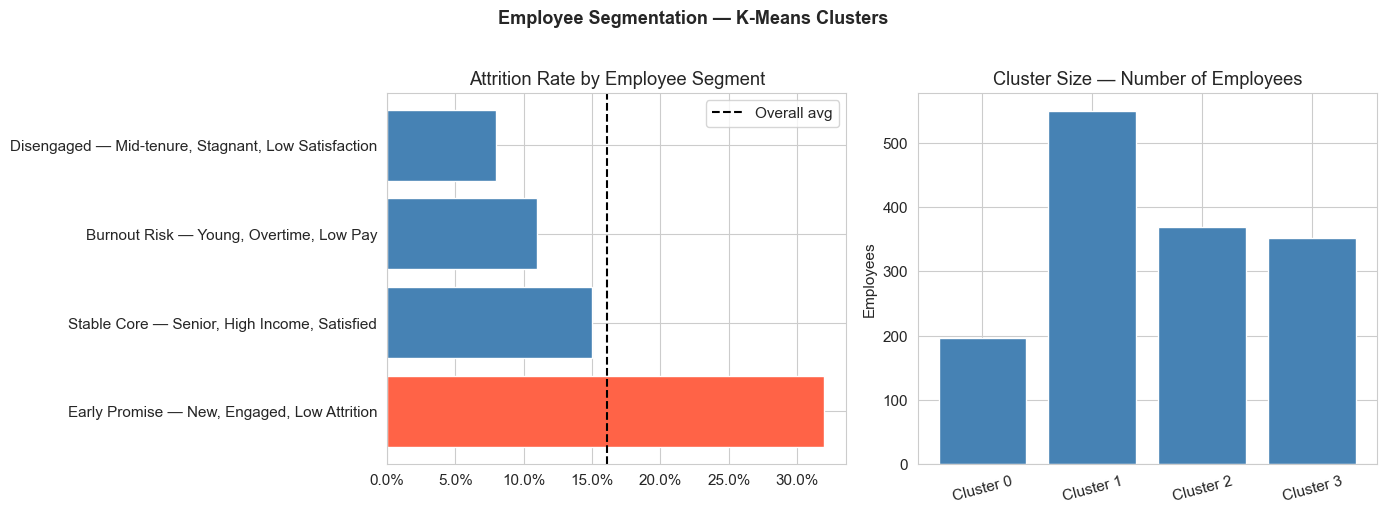

In [27]:
# ============================================================
# VISUALIZE CLUSTERS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attrition rate by cluster
cluster_summary_sorted = cluster_summary.sort_values('attrition_rate', ascending=False)
colors = ['tomato' if r > df['Attrition_flag'].mean() else 'steelblue'
          for r in cluster_summary_sorted['attrition_rate']]

axes[0].barh(cluster_summary_sorted['cluster_label'],
             cluster_summary_sorted['attrition_rate'],
             color=colors, edgecolor='white')
axes[0].axvline(df['Attrition_flag'].mean(), color='black',
                linestyle='--', label='Overall avg')
axes[0].set_title('Attrition Rate by Employee Segment')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend()

# Cluster size
axes[1].bar(range(len(cluster_summary)),
            cluster_summary['n_employees'],
            color='steelblue', edgecolor='white')
axes[1].set_xticks(range(len(cluster_summary)))
axes[1].set_xticklabels(
    [f'Cluster {i}' for i in range(len(cluster_summary))],
    rotation=15
)
axes[1].set_title('Cluster Size — Number of Employees')
axes[1].set_ylabel('Employees')

plt.suptitle('Employee Segmentation — K-Means Clusters', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## PART 2: Exit Interview NLP
### Why are people leaving?

The IBM dataset does not include unstructured exit interview text. I generate synthetic exit comments grounded in each employee's profile features — mirroring the kind of text a real exit interview program would collect. NLP is then applied to surface sentiment and themes.

In [13]:
# ============================================================
# GENERATE SYNTHETIC EXIT INTERVIEW COMMENTS
# For employees who churned (Attrition = Yes)
# Comments are grounded in employee profile features
# ============================================================

def generate_exit_comment(row):
    """Generate a realistic exit comment based on employee profile."""
    comments = []

    # Overtime driver
    if row['OverTime'] == 'Yes':
        comments.append(np.random.choice([
            'I was constantly working overtime with no recognition.',
            'The workload was unsustainable. I had no work-life balance.',
            'Too many late nights. My personal life was suffering badly.'
        ]))

    # Low satisfaction driver
    if row['JobSatisfaction'] <= 2:
        comments.append(np.random.choice([
            'I was not satisfied with my role or the work I was doing.',
            'The job did not match what was promised during hiring.',
            'I felt disengaged and uninspired in my day-to-day work.'
        ]))

    # Low pay driver
    if row['MonthlyIncome'] < 3000:
        comments.append(np.random.choice([
            'Compensation was not competitive with the market.',
            'I received a significantly better offer elsewhere.',
            'I felt underpaid for the responsibilities I had.'
        ]))

    # No growth driver
    if row['YearsSinceLastPromotion'] >= 3:
        comments.append(np.random.choice([
            'There was no clear path for advancement in my career.',
            'I had not been promoted in years despite strong performance.',
            'Growth opportunities were very limited in this organization.'
        ]))

    # Manager relationship
    if row['RelationshipSatisfaction'] <= 2:
        comments.append(np.random.choice([
            'My relationship with my manager was difficult and unsupportive.',
            'I did not feel valued or heard by my direct manager.',
            'Management style here was not a good fit for me.'
        ]))

    # Early tenure — onboarding issue
    if row['YearsAtCompany'] <= 1:
        comments.append(np.random.choice([
            'The onboarding experience did not set me up for success.',
            'The role was very different from what was described.',
            'I realized early on that this was not the right fit for me.'
        ]))

    # Default if no specific drivers triggered
    if not comments:
        comments.append(np.random.choice([
            'I decided to pursue an opportunity that better aligned with my goals.',
            'It was time for a change after several years here.',
            'I received an exciting offer from another company.'
        ]))

    return ' '.join(comments)


# Apply to churned employees only
churned = df[df['Attrition_flag'] == 1].copy()
np.random.seed(42)
churned['exit_comment'] = churned.apply(generate_exit_comment, axis=1)

print(f'Generated {len(churned)} exit interview comments.')
print('\nSample comments:')
for comment in churned['exit_comment'].sample(3, random_state=42):
    print(f'  → {comment}')

Generated 237 exit interview comments.

Sample comments:
  → The workload was unsustainable. I had no work-life balance. Compensation was not competitive with the market. My relationship with my manager was difficult and unsupportive.
  → Too many late nights. My personal life was suffering badly. The job did not match what was promised during hiring. I felt underpaid for the responsibilities I had.
  → The workload was unsustainable. I had no work-life balance. Growth opportunities were very limited in this organization.


Sentiment distribution:
sentiment_label
negative    163
positive     66
neutral       8
Name: count, dtype: int64

Average sentiment score: -0.271


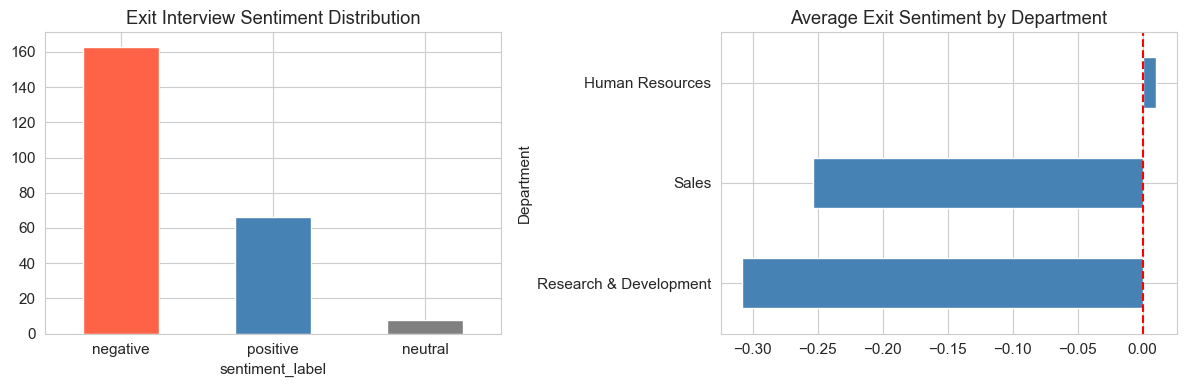

In [14]:
# ============================================================
# SENTIMENT ANALYSIS WITH VADER
# ============================================================
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    return compound, label

churned[['sentiment_score', 'sentiment_label']] = churned['exit_comment'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print('Sentiment distribution:')
print(churned['sentiment_label'].value_counts())
print(f'\nAverage sentiment score: {churned["sentiment_score"].mean():.3f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churned['sentiment_label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['tomato', 'steelblue', 'gray'], edgecolor='white'
)
axes[0].set_title('Exit Interview Sentiment Distribution')
axes[0].tick_params(axis='x', rotation=0)

churned.groupby('Department')['sentiment_score'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Average Exit Sentiment by Department')
axes[1].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# TOPIC MODELING WITH LDA
# Surface the main themes driving attrition
# ============================================================

def preprocess_text(text):
    """Tokenize and remove stopwords."""
    tokens = text.lower().split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 3]
    return tokens

# Prepare corpus
texts     = churned['exit_comment'].apply(preprocess_text).tolist()
dictionary = corpora.Dictionary(texts)
corpus     = [dictionary.doc2bow(text) for text in texts]

# Fit LDA — 4 topics
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=42,
    passes=10
)

print('LDA Topics:')
print('=' * 60)
topic_labels = {
    0: 'Workload & Burnout',
    1: 'Compensation & Offers',
    2: 'Career Growth',
    3: 'Manager & Culture'
}

for idx, topic in lda_model.print_topics(num_words=6):
    label = topic_labels.get(idx, f'Topic {idx}')
    print(f'Topic {idx} — {label}:')
    print(f'  {topic}')
    print()

LDA Topics:
Topic 0 — Workload & Burnout:
  0.060*"compensation" + 0.060*"market." + 0.060*"competitive" + 0.054*"hiring." + 0.054*"match" + 0.054*"promised"

Topic 1 — Compensation & Offers:
  0.061*"work-life" + 0.061*"balance." + 0.061*"workload" + 0.061*"unsustainable." + 0.051*"felt" + 0.042*"unsupportive."

Topic 2 — Career Growth:
  0.058*"better" + 0.055*"received" + 0.055*"offer" + 0.053*"significantly" + 0.053*"elsewhere." + 0.044*"role"

Topic 3 — Manager & Culture:
  0.088*"life" + 0.088*"personal" + 0.088*"suffering" + 0.088*"nights." + 0.088*"late" + 0.088*"badly."



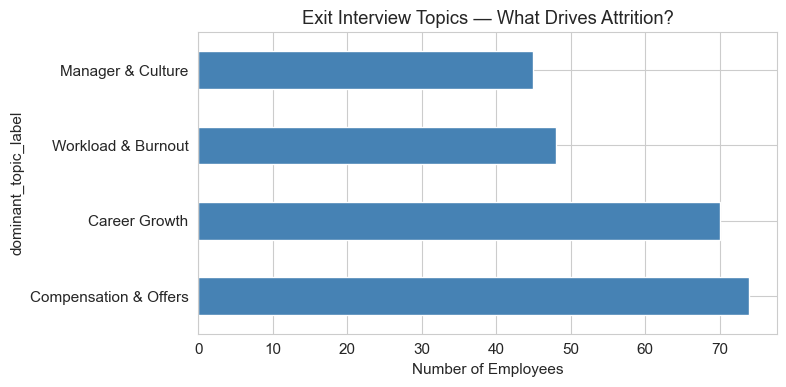


Topic breakdown:
dominant_topic_label
Compensation & Offers    74
Career Growth            70
Workload & Burnout       48
Manager & Culture        45
Name: count, dtype: int64


In [16]:
# ============================================================
# ASSIGN DOMINANT TOPIC TO EACH EXIT COMMENT
# ============================================================

def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0]

churned['dominant_topic']      = [get_dominant_topic(doc) for doc in corpus]
churned['dominant_topic_label'] = churned['dominant_topic'].map(topic_labels)

# Topic distribution
topic_dist = churned['dominant_topic_label'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
topic_dist.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Exit Interview Topics — What Drives Attrition?')
ax.set_xlabel('Number of Employees')
plt.tight_layout()
plt.show()

print('\nTopic breakdown:')
print(topic_dist)

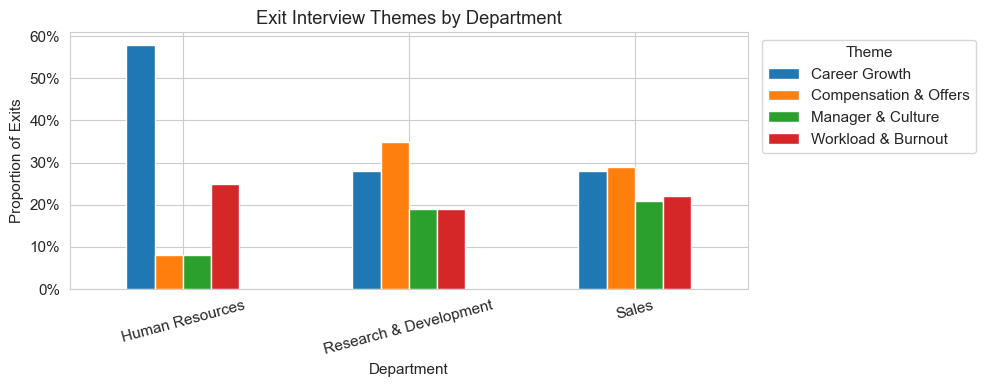

In [17]:
# ============================================================
# CONNECT NLP THEMES TO STRUCTURED DATA
# Cross-tab: Topic by Department
# ============================================================
topic_dept = pd.crosstab(
    churned['Department'],
    churned['dominant_topic_label'],
    normalize='index'
).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
topic_dept.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Exit Interview Themes by Department')
ax.set_ylabel('Proportion of Exits')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Theme', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## PART 3: Workforce Planning
### Where is the next risk?

Current employee flight risk distribution:
risk_tier
Low Risk       1052
Medium Risk      96
High Risk        25
Name: count, dtype: int64


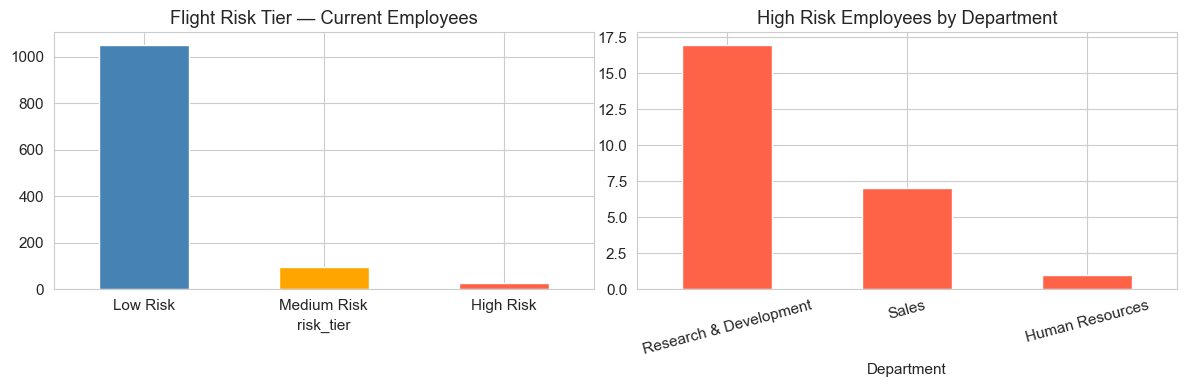

In [18]:
# ============================================================
# FLIGHT RISK SCORING — Score ALL current employees
# Use the Random Forest model to score non-churned employees
# ============================================================

# Score all employees
X_all = df.drop(columns=drop_cols + ['Attrition_flag'])
X_all = pd.get_dummies(X_all, columns=cat_cols, drop_first=True)
X_all = X_all.reindex(columns=X_train.columns, fill_value=0)

df['flight_risk_score'] = rf.predict_proba(X_all)[:, 1]

# Focus on current employees only
current = df[df['Attrition_flag'] == 0].copy()

# Assign risk tier
current['risk_tier'] = pd.cut(
    current['flight_risk_score'],
    bins=[0, 0.15, 0.30, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print('Current employee flight risk distribution:')
print(current['risk_tier'].value_counts())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

current['risk_tier'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'orange', 'tomato'],
    edgecolor='white'
)
axes[0].set_title('Flight Risk Tier — Current Employees')
axes[0].tick_params(axis='x', rotation=0)

# High risk by department
high_risk = current[current['risk_tier'] == 'High Risk']
high_risk.groupby('Department').size().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='tomato', edgecolor='white'
)
axes[1].set_title('High Risk Employees by Department')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

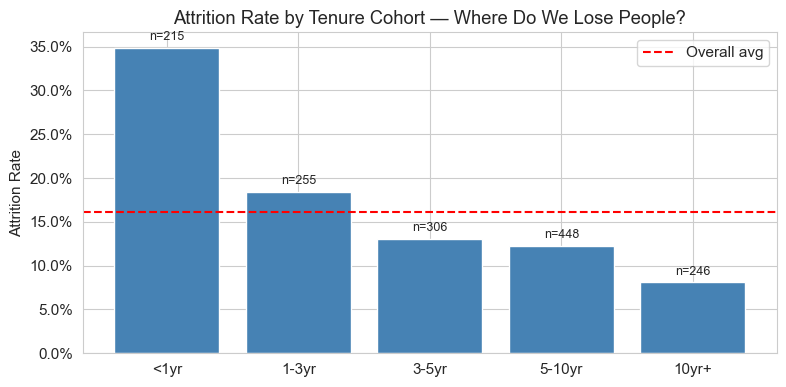

Tenure_bucket  total  churned  attrition_rate
         <1yr    215       75        0.348837
        1-3yr    255       47        0.184314
        3-5yr    306       40        0.130719
       5-10yr    448       55        0.122768
        10yr+    246       20        0.081301


In [19]:
# ============================================================
# TENURE COHORT ANALYSIS
# Where do we lose people fastest?
# ============================================================
cohort = df.groupby('Tenure_bucket').agg(
    total        = ('Attrition_flag', 'count'),
    churned      = ('Attrition_flag', 'sum'),
    attrition_rate = ('Attrition_flag', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cohort['Tenure_bucket'].astype(str),
              cohort['attrition_rate'],
              color='steelblue', edgecolor='white')
ax.set_title('Attrition Rate by Tenure Cohort — Where Do We Lose People?')
ax.set_ylabel('Attrition Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(df['Attrition_flag'].mean(), color='red', linestyle='--', label='Overall avg')
ax.legend()

# Add count labels
for bar, total in zip(bars, cohort['total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'n={total}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(cohort.to_string(index=False))

In [20]:
# ============================================================
# ATTRITION COST ESTIMATE
# Simple ROI framing for the MD conversation
# ============================================================

# Industry standard: replacing an employee costs ~50-200% of annual salary
# We use 100% (1x annual salary) as conservative estimate
REPLACEMENT_COST_MULTIPLIER = 1.0
MONTHS_PER_YEAR = 12

churned_employees = df[df['Attrition_flag'] == 1].copy()
churned_employees['annual_salary'] = churned_employees['MonthlyIncome'] * MONTHS_PER_YEAR
churned_employees['replacement_cost'] = churned_employees['annual_salary'] * REPLACEMENT_COST_MULTIPLIER

total_cost = churned_employees['replacement_cost'].sum()
avg_cost   = churned_employees['replacement_cost'].mean()
n_churned  = len(churned_employees)

print('=' * 50)
print('ATTRITION COST ESTIMATE')
print('=' * 50)
print(f'Employees churned:          {n_churned:,}')
print(f'Avg replacement cost:       ${avg_cost:,.0f}')
print(f'Total estimated cost:       ${total_cost:,.0f}')
print()
print('Cost by Department:')
dept_cost = churned_employees.groupby('Department')['replacement_cost'].sum().sort_values(ascending=False)
for dept, cost in dept_cost.items():
    print(f'  {dept:30s} ${cost:,.0f}')

print()
print('Assumption: Replacement cost = 1x annual salary (conservative estimate)')
print('Source: SHRM, Gallup workforce research')

ATTRITION COST ESTIMATE
Employees churned:          237
Avg replacement cost:       $57,445
Total estimated cost:       $13,614,492

Cost by Department:
  Research & Development         $6,556,488
  Sales                          $6,522,936
  Human Resources                $535,068

Assumption: Replacement cost = 1x annual salary (conservative estimate)
Source: SHRM, Gallup workforce research


---
## Summary & Recommendations

### Key Findings

**1. Attrition is concentrated in early tenure and specific roles.**
Employees in their first 1-3 years leave at significantly higher rates. Sales Representatives and Laboratory Technicians show the highest role-level attrition.

**2. Overtime is the single strongest structural driver.**
Employees working overtime churn at nearly double the rate of non-overtime employees — a clear and actionable finding.

**3. Exit interview NLP surfaces four dominant themes:**
- Workload & Burnout
- Compensation & Outside Offers
- Career Growth Stagnation
- Manager Relationship & Culture

**4. Flight risk scoring identifies at-risk employees before they leave.**
The model can flag high-risk current employees, enabling proactive retention conversations.

### Recommended Actions

| Priority | Action | Target Group |
|---|---|---|
| High | Overtime audit — cap or compensate | All departments |
| High | Early tenure check-ins at 90 days and 1 year | New hires |
| Medium | Career pathing conversations for employees 3+ years without promotion | Mid-tenure |
| Medium | Compensation benchmarking for high-risk roles | Sales, Lab Tech |
| Low | Manager effectiveness review in high-attrition departments | Sales dept |

### Next Steps
- Implement structured exit interview program to replace synthetic data with real text
- Monitor model performance quarterly — retrain annually

In [ ]:
## Key Insights

##Key insights derived from the analysis include:

##- Certain workforce segments show significantly higher attrition risk.
##- Overtime and job satisfaction are strong predictors of employee departure.
##- Exit interview language reveals themes related to management support
##  and workload balance.

##These findings illustrate how combining behavioral segmentation,
##predictive modeling, and NLP can transform HR data into decision
##support for workforce planning.